# Part 3 Khushi Gohel KKG786


# Section 1: Review of Part 2

The stiff system is a chemical reaction where concentration $C(t)$ rapidly approaches a slowly varying equilibrium concentration.

$$
\frac{dC}{dt} = -k(C - C_{eq}(t))
$$


$$
C_{eq}(t) = 1 + 0.1\sin(0.1t)
$$

Using $k = 10^4$, the ODE becomes:

$$
\frac{dC}{dt} = -10^4C + 10^4(1 + 0.1\sin(0.1t))
$$



- $C(t)$ isconcentration
- $C_{eq}(t)$ is the equilibrium concentration
- $k$ is the reaction rate

The problem is stiff because the reaction occurs very fast, but the equilibrium changes slowly.
The fast time scale is $1/10^4 = 0.0001$ seconds, while the slow time scale is $1/0.1 = 10$ seconds.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# parameters
k = 10**4
C0 = 0.0
t0 = 0.0
t_final = 10.0

# Slowly varying equilibrium concentration
def C_eq(t):
    return 1 + 0.1 * np.sin(0.1 * t)

# ODE function
# dC/dt = -k(C - C_eq(t))
def f_ode(t, C):
    return -k * (C - C_eq(t))

# Derivative of f with respect to C
def fprime(C):
    return -k

print("Reaction rate k =", k)
print("Initial concentration C0 =", C0)
print("Stiffness ratio =", (1/0.1)/(1/k))

Reaction rate k = 10000
Initial concentration C0 = 0.0
Stiffness ratio = 100000.0


# Section 2: Newton-Raphson Damping Implementation

Basic Newton-Raphson uses:

x_new = x - g(x) / g'(x)

Damped Newton-Raphson modifies this by adding a damping factor $\alpha$:

x_new = x - $\alpha$ * g(x) / g'(x)

The line search starts with $\alpha$ = 1. If the residual does not decrease, $\alpha$ is cut in half.


In [ ]:
# Residual for Backward Euler
def residual(C_next, C_old, t_next, h):
    return C_next - C_old - h * f_ode(t_next, C_next)

# Derivative of residual
# Since f'(C) = -k, this becomes 1 + h*k.
def residual_prime(h):
    return 1 - h * fprime(0)


# Basic Newton-Raphson solver
def basic_newton_raphson(y_n, t_next, h, g_func, g_prime_func,
                         tol=1e-8, max_iter=20):
    y_guess = y_n
    residual_history = []

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        residual_history.append(abs(g))

        if abs(g) < tol:
            return y_guess, k, True, residual_history

        g_prime = g_prime_func(h)
        delta = -g / g_prime
        y_guess = y_guess + delta

    return y_guess, max_iter, False, residual_history


# Damped Newton-Raphson with line search
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func,
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n

    residual_history = []
    alpha_history = []
    backtrack_history = []

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        residual_history.append(abs(g))

        if abs(g) < tol:
            return y_guess, k, True, residual_history, alpha_history, backtrack_history

        g_prime = g_prime_func(h)
        delta = -g / g_prime

        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        backtracks = 0

        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))

            if g_new < g_current:  # Sufficient decrease
                break

            alpha = alpha / 2.0
            backtracks += 1

            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False, residual_history, alpha_history, backtrack_history

        alpha_history.append(alpha)
        backtrack_history.append(backtracks)
        y_guess = y_new

    return y_guess, max_iter, False, residual_history, alpha_history, backtrack_history


Testing undamped NR with h = 2.0:
Converged: True, iterations: 1

Testing damped NR with h = 2.0:
Converged: True, iterations: 1
Backtracking steps: 0


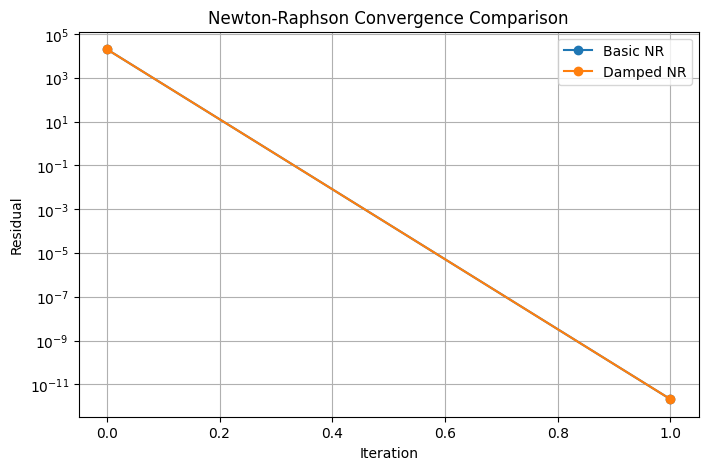

In [ ]:
# Test 1

h_large = 2.0  # Very large step size

print("Testing undamped NR with h = 2.0:")
try:
    C_basic, it_basic, success_basic, res_basic = basic_newton_raphson(
        C0, t0 + h_large, h_large, residual, residual_prime
    )
    print(f"Converged: {success_basic}, iterations: {it_basic}")
except:
    print("Failed to converge!")

print("\nTesting damped NR with h = 2.0:")
C_damped, it_damped, success_damped, res_damped, alpha_hist, backtrack_hist = damped_newton_raphson(
    C0, t0 + h_large, h_large, residual, residual_prime
)
print(f"Converged: {success_damped}, iterations: {it_damped}")
print("Backtracking steps:", sum(backtrack_hist))

plt.figure(figsize=(8,5))
plt.semilogy(res_basic, 'o-', label='Basic NR')
plt.semilogy(res_damped, 'o-', label='Damped NR')
plt.xlabel('Iteration')
plt.ylabel('Residual')
plt.title('Newton-Raphson Convergence Comparison')
plt.legend()
plt.grid(True)
plt.show()


Basic Newton-Raphson converges quickly. The damped version is still more better because it checks that the residual decreases before accepting the Newton step.

#Section 3: Adaptive Step Size Implementation

Step-doubling compares one step of size \(h\) with two steps of size \(h/2\).

The difference estimates the error and is used to adjust the step size.

In [ ]:
# One Backward Euler step using damped Newton-Raphson
def backward_euler_step_damped(C_old, t_next, h, nr_tol=1e-8):
    C_next, iters, success, residual_history, alpha_history, backtrack_history = damped_newton_raphson(
        C_old, t_next, h, residual, residual_prime, tol=nr_tol
    )
    return C_next, iters


def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    # Single step of size h
    y_full, iters_full = nr_solver(y_n, t_n + h, h)

    # Two half-steps of size h/2
    y_half_1, iters_1 = nr_solver(y_n, t_n + h/2, h/2)
    y_half, iters_2 = nr_solver(y_half_1, t_n + h, h/2)


    error = abs(y_half - y_full)

    # Total NR iterations for this error estimate
    total_iters = iters_full + iters_1 + iters_2

    return y_full, y_half, error, total_iters


def adaptive_step(y_n, t_n, h, tol, nr_solver,
                  h_min=1e-6, h_max=1.0, safety=0.9):

    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver
    )

    # Compute new step size suggestion
    if error < 1e-14:
        h_new = min(2.0 * h, h_max)
    else:
        # Standard formula: h_new = h * sqrt(tol/err)
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))


    h_new = max(0.2 * h, min(5.0 * h, h_new))


    if error < tol:

        return y_half, h, h_new, True, iters, error
    else:

        return y_n, h, h_new, False, iters, error


def adjust_step_size(h_current, error, tol, safety=0.9,
                     h_min=1e-6, h_max=1.0):
    """
    Compute new step size based on error estimate

    Uses: h_new = h * sqrt(tol / err)
    """
    if error < 1e-14:  # Very small error, increase moderately
        h_new = h_current * 2.0
    else:
        h_new = h_current * np.sqrt(tol / error)

    # Apply safety factor
    h_new = safety * h_new

    # Enforce bounds
    h_new = max(h_min, min(h_max, h_new))


    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new


# Adaptive Implicit Euler using the teacher's adaptive step functions
def adaptive_backward_euler(C0, t0, t_final, h0, tol=1e-4, h_min=1e-6, h_max=1.0):
    t_values = [t0]
    C_values = [C0]
    h_history = []
    error_history = []
    accepted_history = []
    nr_iterations = []

    stats = {
        "accepted_steps": 0,
        "rejected_steps": 0,
        "nr_iterations": [],
        "function_evals": 0
    }

    h = h0

    while t_values[-1] < t_final:
        t_n = t_values[-1]
        y_n = C_values[-1]

        if t_n + h > t_final:
            h = t_final - t_n

        def nr_solver(y_old, t_next, h_step):
            return backward_euler_step_damped(y_old, t_next, h_step)

        y_next, h_used, h_new, accepted, iters, error = adaptive_step(
            y_n, t_n, h, tol, nr_solver, h_min=h_min, h_max=h_max
        )

        stats["nr_iterations"].append(iters)
        stats["function_evals"] += iters

        if accepted:
            t_values.append(t_n + h_used)
            C_values.append(y_next)
            h_history.append(h_used)
            error_history.append(error)
            accepted_history.append(1)
            stats["accepted_steps"] += 1
            h = h_new
        else:
            error_history.append(error)
            accepted_history.append(0)
            stats["rejected_steps"] += 1
            h = h_new

    stats["total_NR_iterations"] = int(np.sum(stats["nr_iterations"]))

    return (np.array(t_values), np.array(C_values), np.array(h_history),
            np.array(error_history), np.array(accepted_history), np.array(stats["nr_iterations"]), stats)


In [ ]:
# Run adaptive solver
(t_adapt, C_adapt, h_hist, err_hist, accepted_hist,
 nr_hist, stats_adapt) = adaptive_backward_euler(
    C0, t0, t_final, h0=0.1, tol=1e-4, h_min=1e-6, h_max=1.0
)

print("Adaptive solver statistics")
print("accepted_steps =", stats_adapt["accepted_steps"])
print("rejected_steps =", stats_adapt["rejected_steps"])
print("function_evals =", stats_adapt["function_evals"])
print("total_NR_iterations =", stats_adapt["total_NR_iterations"])
print("Number of solution points =", len(t_adapt))


Adaptive solver statistics
accepted_steps = 126
rejected_steps = 7
function_evals = 399
total_NR_iterations = 399
Number of solution points = 127


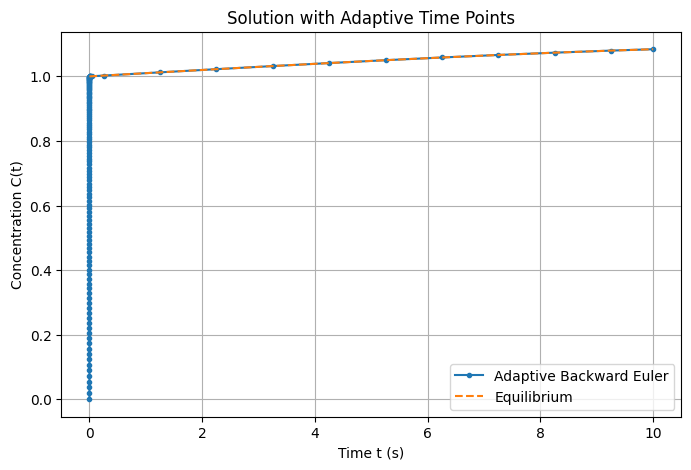

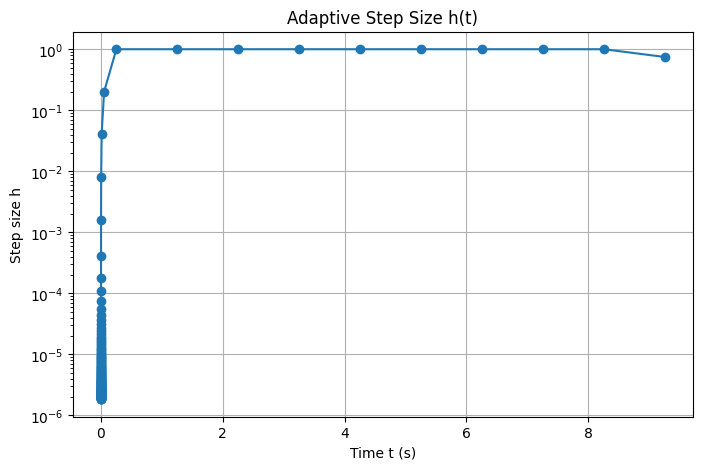

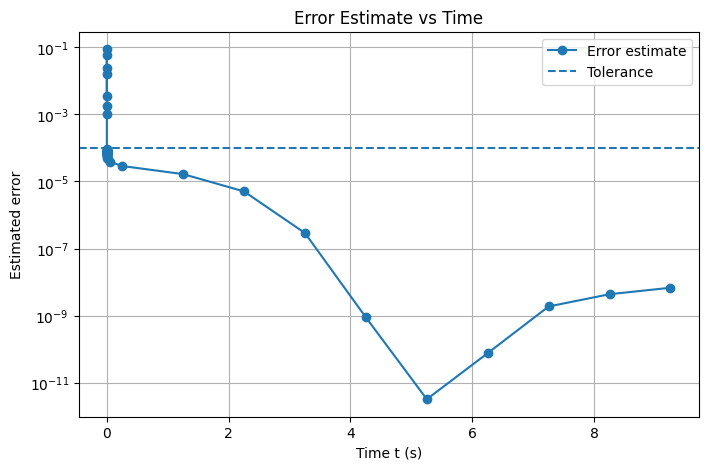

In [ ]:
# Solution with adaptive time points
plt.figure(figsize=(8,5))
plt.plot(t_adapt, C_adapt, 'o-', markersize=3, label='Adaptive Backward Euler')
plt.plot(t_adapt, C_eq(t_adapt), '--', label='Equilibrium')
plt.xlabel('Time t (s)')
plt.ylabel('Concentration C(t)')
plt.title('Solution with Adaptive Time Points')
plt.legend()
plt.grid(True)
plt.show()

# Step size history
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[:-1], h_hist, 'o-')
plt.xlabel('Time t (s)')
plt.ylabel('Step size h')
plt.title('Adaptive Step Size h(t)')
plt.grid(True)
plt.show()

# Error estimate history
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[:-1], err_hist[:len(h_hist)], 'o-', label='Error estimate')
plt.axhline(1e-4, linestyle='--', label='Tolerance')
plt.xlabel('Time t (s)')
plt.ylabel('Estimated error')
plt.title('Error Estimate vs Time')
plt.legend()
plt.grid(True)
plt.show()

# Section 4: Performance Analysis

In [ ]:
# Test 2

# Fixed step Backward Euler method
def backward_euler_fixed(C0, t0, t_final, h):
    t_values = np.arange(t0, t_final + h, h)
    if t_values[-1] > t_final:
        t_values[-1] = t_final

    C_values = np.zeros(len(t_values))
    iterations = []
    C_values[0] = C0

    for i in range(1, len(t_values)):
        h_step = t_values[i] - t_values[i-1]
        C_next, iters = backward_euler_step_damped(C_values[i-1], t_values[i], h_step)
        C_values[i] = C_next
        iterations.append(iters)

    return t_values, C_values, np.array(iterations)


# Fixed method baseline
t_fixed, C_fixed, it_fixed = backward_euler_fixed(C0, t0, t_final, h=0.01)

fixed_error = abs(C_fixed[-1] - C_eq(t_final))
adaptive_error = abs(C_adapt[-1] - C_eq(t_final))

performance_data = {
    "Method": ["Fixed (h=0.01)", "Adaptive"],
    "Steps": [len(t_fixed)-1, stats_adapt["accepted_steps"]],
    "Rejected Steps": [0, stats_adapt["rejected_steps"]],
    "Function Evals": [int(np.sum(it_fixed)), stats_adapt["function_evals"]],
    "Final Error": [fixed_error, adaptive_error]
}

performance_table = pd.DataFrame(performance_data)
performance_table


,Method,Steps,Rejected Steps,Function Evals,Final Error
0,Fixed (h=0.01),1000,0,1000,5.407314e-07
1,Adaptive,126,7,399,5.558981e-07


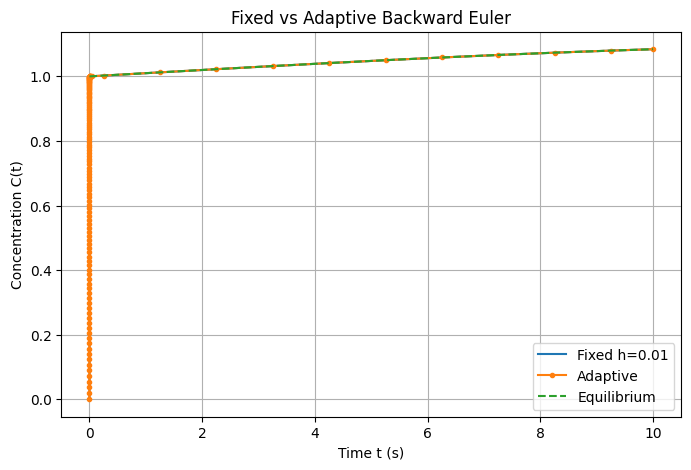

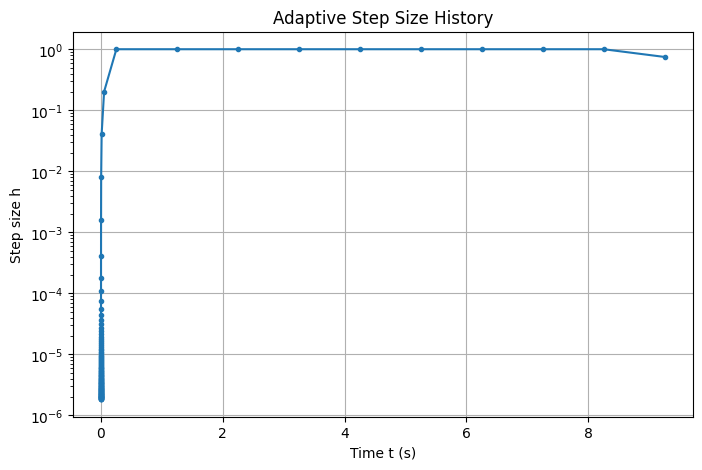

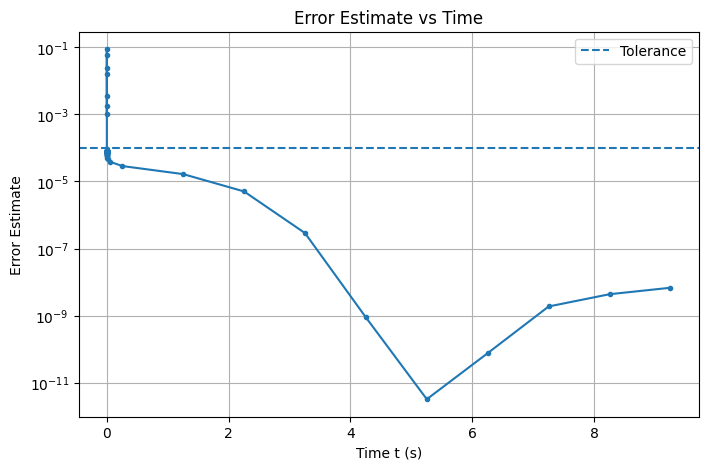

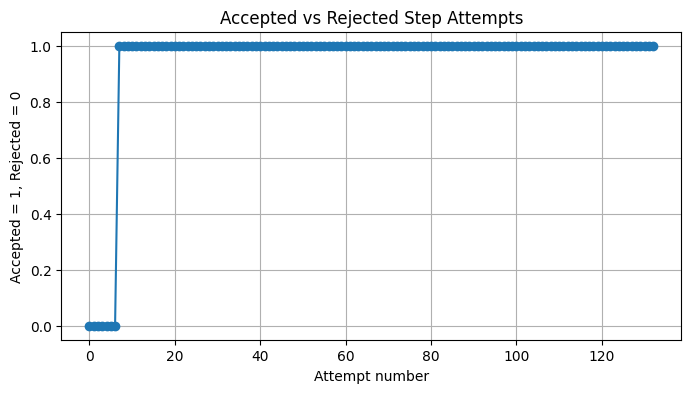

In [ ]:
tol = 1e-4

# Solution with adaptive time points
plt.figure(figsize=(8,5))
plt.plot(t_fixed, C_fixed, label='Fixed h=0.01')
plt.plot(t_adapt, C_adapt, 'o-', markersize=3, label='Adaptive')
plt.plot(t_adapt, C_eq(t_adapt), '--', label='Equilibrium')
plt.xlabel('Time t (s)')
plt.ylabel('Concentration C(t)')
plt.title('Fixed vs Adaptive Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

# Step size h(t) vs time
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[:-1], h_hist, 'o-', markersize=3)
plt.xlabel('Time t (s)')
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)
plt.show()

# Error estimate vs time
plt.figure(figsize=(8,5))
plt.semilogy(t_adapt[:-1], err_hist[:len(h_hist)], 'o-', markersize=3)
plt.axhline(y=tol, linestyle='--', label='Tolerance')
plt.xlabel('Time t (s)')
plt.ylabel('Error Estimate')
plt.title('Error Estimate vs Time')
plt.legend()
plt.grid(True)
plt.show()

# Accepted vs rejected step attempts
plt.figure(figsize=(8,4))
plt.plot(accepted_hist, 'o-')
plt.xlabel('Attempt number')
plt.ylabel('Accepted = 1, Rejected = 0')
plt.title('Accepted vs Rejected Step Attempts')
plt.grid(True)
plt.show()


Even though the adaptive approach requires relatively higher costs in per step attempt, due to its use of step doubling, it is capable of making larger steps during regions where the function is relatively smoother.

# Section 5: Robustness Testing


Large initial step size test
{'accepted_steps': 11, 'rejected_steps': 0, 'nr_iterations': [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], 'function_evals': 33, 'total_NR_iterations': 33}


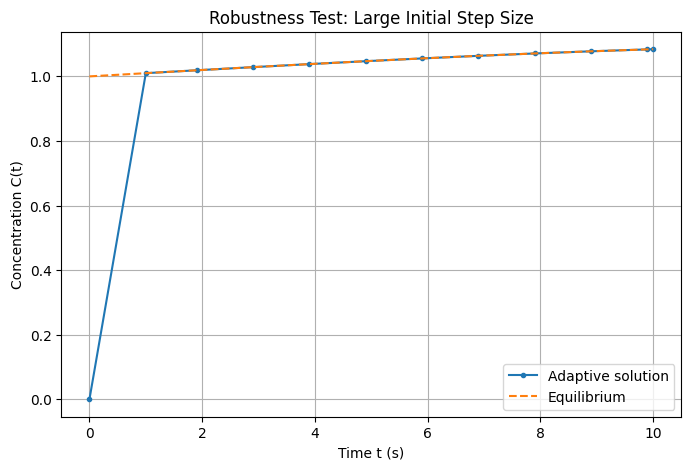

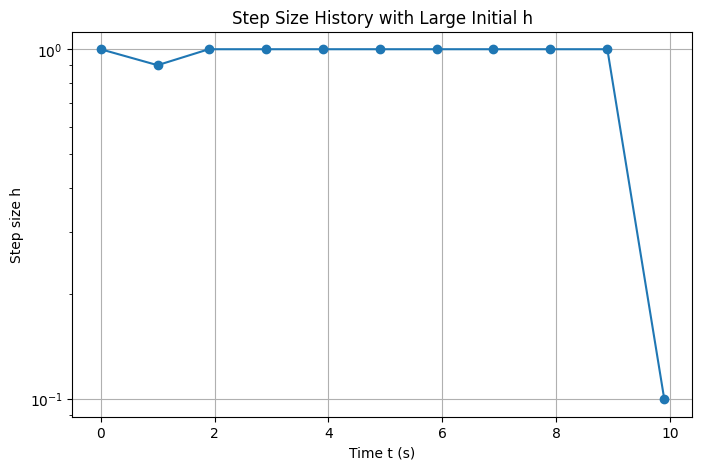

In [ ]:
# Test 1
(t_large, C_large, h_large_hist, err_large, acc_large,
 nr_large, stats_large) = adaptive_backward_euler(
    C0, t0, t_final, h0=1.0, tol=1e-4, h_min=1e-6, h_max=1.0
)

print("Large initial step size test")
print(stats_large)

plt.figure(figsize=(8,5))
plt.plot(t_large, C_large, 'o-', markersize=3, label='Adaptive solution')
plt.plot(t_large, C_eq(t_large), '--', label='Equilibrium')
plt.xlabel('Time t (s)')
plt.ylabel('Concentration C(t)')
plt.title('Robustness Test: Large Initial Step Size')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy(t_large[:-1], h_large_hist, 'o-')
plt.xlabel('Time t (s)')
plt.ylabel('Step size h')
plt.title('Step Size History with Large Initial h')
plt.grid(True)
plt.show()

Tight tolerance test
accepted_steps = 5
rejected_steps = 0
function_evals = 15


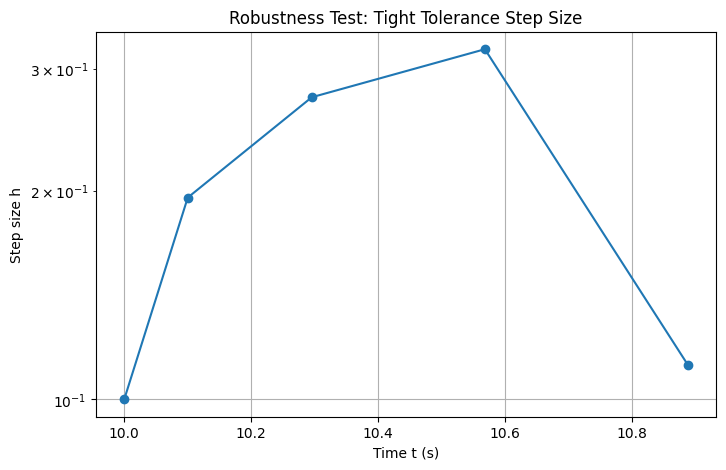

In [ ]:
# very tight tolerance
t_tight_start = t_adapt[-1]
C_tight_start = C_adapt[-1]
t_tight_final = t_tight_start + 1.0

(t_tight, C_tight, h_tight_hist, err_tight, acc_tight,
 nr_tight, stats_tight) = adaptive_backward_euler(
    C_tight_start, t_tight_start, t_tight_final, h0=0.1, tol=1e-8, h_min=1e-6, h_max=1.0
)

print("Tight tolerance test")
print("accepted_steps =", stats_tight["accepted_steps"])
print("rejected_steps =", stats_tight["rejected_steps"])
print("function_evals =", stats_tight["function_evals"])

plt.figure(figsize=(8,5))
plt.semilogy(t_tight[:-1], h_tight_hist, 'o-')
plt.xlabel('Time t (s)')
plt.ylabel('Step size h')
plt.title('Robustness Test: Tight Tolerance Step Size')
plt.grid(True)
plt.show()


The large step size test indicates that the solver has the ability to reduce the step size without failing. Additionally, the small tolerance test proves that the solver is capable of taking smaller step sizes due to a need for higher precision.

# Section 6: Conclusions
Damping is useful since it enables Newton-Raphson to ignore increases in the residual function. Adaptive step size selection is useful since it enables smaller steps in harder areas and larger steps in smoother areas. In summary, damping Newton-Raphson along with adaptive Backward Euler results in the stiff ODE solver being better than a fixed step method.
